# top

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

%reload_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


# image of a square

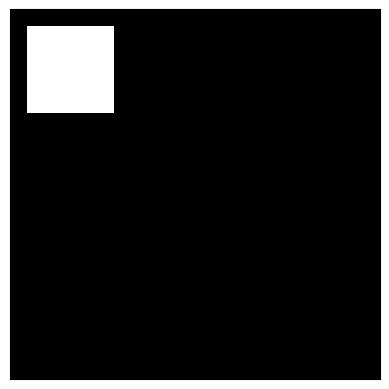

In [2]:
from a_datasets.circle_in_square.data import make_square

tensor = make_square(64, 1, 0, 10, 10, 8)
fig, ax = plt.subplots(1, 1)
ax.imshow(tensor.squeeze(0), cmap='grey')
plt.setp(ax, xticks=[], yticks=[]);

# image of circle inside square

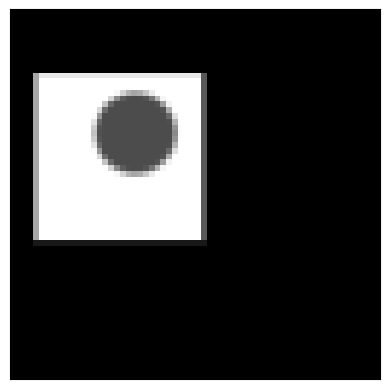

In [3]:
from a_datasets.circle_in_square.data import make_square_with_circle

tensor = make_square_with_circle(
    img_size=64,
    square_foreground=1,
    circle_foreground=0.3,
    background=0,
    square_x=0.1,
    square_y=.30,
    square_width=15,
    circle_radius=8,
    circle_transition_width=2,
    circle_x=0.7,
    circle_y=0.2,
    square_antialias=True,
)

fig, ax = plt.subplots(1, 1)
ax.imshow(tensor.squeeze(), cmap='grey')
plt.setp(ax, xticks=[], yticks=[]);

# distribution of images

In [13]:
from a_datasets.circle_in_square.data import load_cis_data

tensors, (x, y) = load_cis_data()
print(tensors.shape)
print(x.shape)

torch.Size([10000, 1, 64, 64])
torch.Size([10000, 2])


In [17]:
square_x, square_y = x.T

print(square_x.shape)

torch.Size([10000])


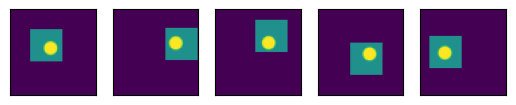

In [18]:
fig, ax = plt.subplots(1, 5)
for i, a in enumerate(ax):
    a.imshow(tensors[i].squeeze())
    plt.setp(a, xticks=[], yticks=[])

In [19]:
from a_datasets.circle_in_square.data import extract_square_position

# tensors, (square_x, square_y), (circle_x, circle_y) = create_square_with_circle_dataset(
#     seed=0,
#     num_images=1e3,
#     img_size=64,
#     circle_radius=6,
#     square_width=12,
#     square_foreground=0.5,
#     circle_foreground=1.0,
#     background=0.0,
#     square_antialias=True,
# )

# now compare against the empirical positions inferred using the position detector
inf_square_x, inf_square_y = extract_square_position(
    tensors,
    square_width=12, 
    square_foreground=0.5, 
    background=0, 
    circle_foreground=1.0
)

diff_x = inf_square_x - square_x
diff_y = inf_square_y - square_y
print(diff_x.mean())
print(diff_y.mean())

tensor(2.6524e-05)
tensor(7.0785e-05)


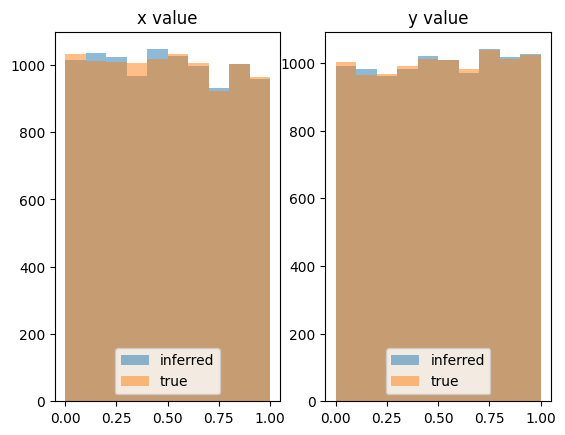

In [20]:
# get a histogram of square x and y values
fig, ax = plt.subplots(1, 2)
ax[0].hist(inf_square_x, alpha=.5, label='inferred')
ax[0].hist(square_x, alpha=.5, label='true')
ax[1].hist(inf_square_y, alpha=.5, label='inferred')
ax[1].hist(square_y, alpha=.5, label='true')

ax[0].set(title='x value')
ax[1].set(title='y value')

ax[0].legend(loc='lower center')
ax[1].legend(loc='lower center')

# smaller image

torch.Size([10000, 1, 28, 28])
torch.Size([10000, 2])


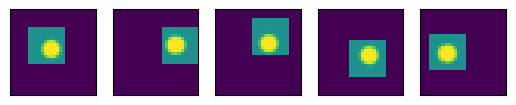

In [8]:
from a_datasets.circle_in_square.data import load_cis_data

tensors, (x, y) = load_cis_data(
    img_size= 28,
    circle_radius= 4,
    square_width= 6,
    circle_transition_width= 2,
    square_antialias= False,
    square_foreground= 0.5,
    circle_foreground= 1.0,
    background= 0.0,
    seed= 42,
)
print(tensors.shape)
print(x.shape)

fig, ax = plt.subplots(1, 5)
for i, a in enumerate(ax):
    a.imshow(tensors[i].squeeze())
    plt.setp(a, xticks=[], yticks=[])